# 08. Regularization and Hyperparameter Tuning
@Shengli (Bruce) Jiang, University of South Carolina

This notebook studies why a regression model can fit the training data well but still perform poorly on new samples.

1. See how additional features affect training and test error
2. Examine strongly correlated wavelength measurements
3. Connect correlation to a flat loss valley
4. Use Ridge to stabilize parameter estimates
5. Compare different regularization strengths
6. Use Lasso to obtain a sparse predictive model
7. Combine Ridge and Lasso with Elastic Net

## Running the notebook

Run the cells from top to bottom. A later cell may use variables created earlier. When finished, restart the kernel and run all cells to confirm that the notebook is reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("tecator.csv")
feature_columns = [f"absorbance_{i}" for i in range(1, 101)]
wavelengths = np.linspace(850, 1050, 100)

X = data[feature_columns].to_numpy()
y = data["fat"].to_numpy()

# Keep one split throughout the notebook so the model comparisons are fair.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=26)

print("Training samples:", len(y_train))
print("Test samples:", len(y_test))

Training samples: 144
Test samples: 96


### The Tecator spectra

Each row of $\mathbf X$ is one near-infrared spectrum. The three samples below are chosen near the 10th, 50th, and 90th percentiles of fat content so we can see the range of the dataset.

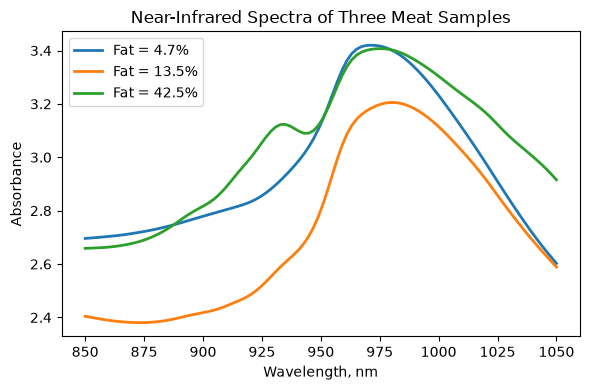

In [2]:
fat_levels = data["fat"].quantile([0.1, 0.5, 0.9])
sample_indices = [(data["fat"] - fat).abs().idxmin() for fat in fat_levels]

fig, ax = plt.subplots(figsize=(6, 4))
for index in sample_indices:
    # The curve is one sample; the 100 x-values are the wavelength features.
    absorbance = data.loc[index, feature_columns].to_numpy(dtype=float)
    ax.plot(wavelengths, absorbance, linewidth=2, label=f"Fat = {data.loc[index, 'fat']:.1f}%")

ax.set(xlabel="Wavelength, nm", ylabel="Absorbance", title="Near-Infrared Spectra of Three Meat Samples")
ax.legend()
fig.tight_layout()
plt.show()

## 1. More features can hurt test performance

Each absorbance measurement gives the linear model another slope parameter. Adding a feature cannot worsen the best ordinary least-squares training fit because its parameter can be set to zero.

Useful features add information. Redundant features add freedom without adding much information. With limited data, this freedom can help the model reproduce training-specific noise.

The test curve below is used only to show the generalization gap. We are not using it to select the number of features.

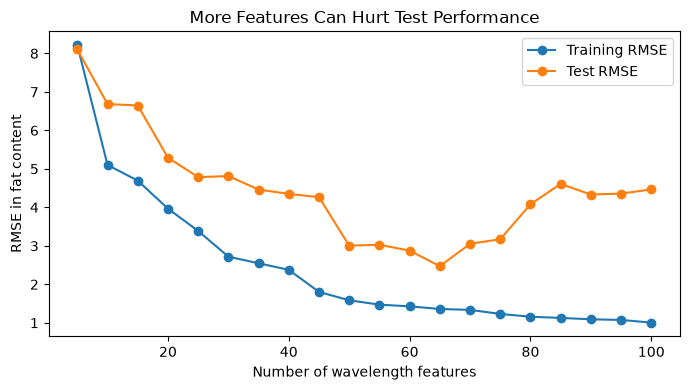

In [3]:
feature_counts = np.arange(5, 101, 5)
train_rmse, test_rmse = [], []

for count in feature_counts:
    # Each model keeps the earlier wavelengths, so the feature sets are nested.
    model = LinearRegression().fit(X_train[:, :count], y_train)
    train_rmse.append(root_mean_squared_error(y_train, model.predict(X_train[:, :count])))
    test_rmse.append(root_mean_squared_error(y_test, model.predict(X_test[:, :count])))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(feature_counts, train_rmse, "o-", label="Training RMSE")
ax.plot(feature_counts, test_rmse, "o-", label="Test RMSE")
ax.set(xlabel="Number of wavelength features", ylabel="RMSE in fat content", title="More Features Can Hurt Test Performance")
ax.legend()
fig.tight_layout()
plt.show()

## 2. Neighboring wavelengths can carry redundant information

Near-infrared spectra change smoothly with wavelength. Measurements at nearby wavelengths can therefore be almost perfectly correlated.

These two wavelengths contain almost same information. The model can exchange parameter weight between them while producing nearly the same prediction.

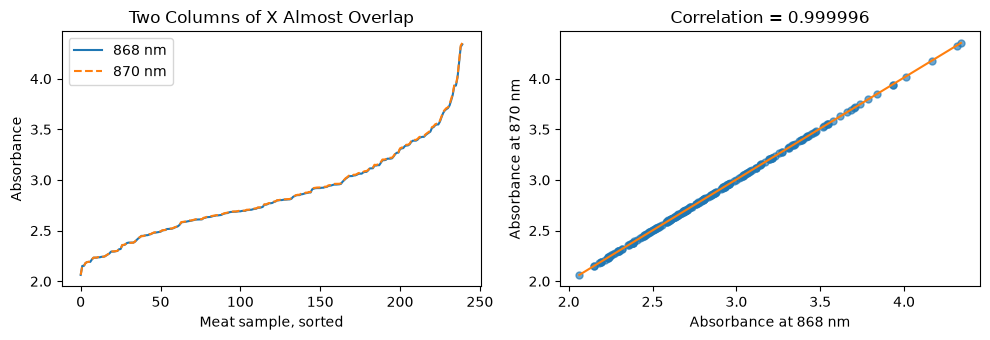

In [4]:
x_1, x_2 = data["absorbance_10"].to_numpy(), data["absorbance_11"].to_numpy()

# Sorting by x_1 makes the overlap between the two columns easier to see.
order = np.argsort(x_1)
correlation = np.corrcoef(x_1, x_2)[0, 1]
slope, intercept = np.polyfit(x_1, x_2, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(x_1[order], label="868 nm")
ax[0].plot(x_2[order], "--", label="870 nm")
ax[0].set(xlabel="Meat sample, sorted", ylabel="Absorbance", title="Two Columns of X Almost Overlap")
ax[0].legend()

ax[1].scatter(x_1, x_2, s=25, alpha=0.65)
ax[1].plot(x_1[order], slope * x_1[order] + intercept, color="C1")
ax[1].set(xlabel="Absorbance at 868 nm", ylabel="Absorbance at 870 nm", title=f"Correlation = {correlation:.6f}")

fig.tight_layout()
plt.show()

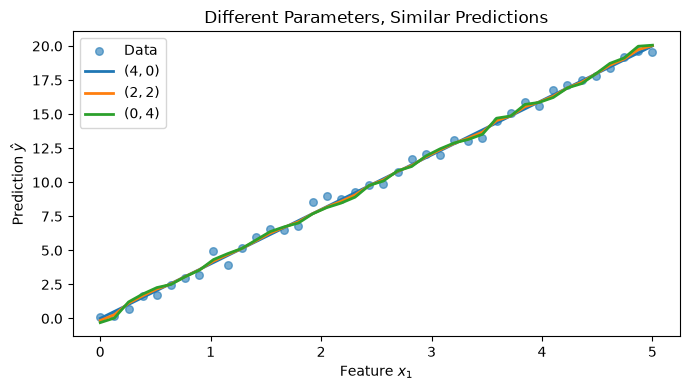

In [5]:
rng_parameters = np.random.default_rng(26)
x_demo = np.linspace(0, 5, 40)
x_demo_2 = x_demo + rng_parameters.normal(0, 0.04, x_demo.size)
y_demo = 4 * x_demo + rng_parameters.normal(0, 0.35, x_demo.size)
parameter_pairs = [(4, 0), (2, 2), (0, 4)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_demo, y_demo, s=30, alpha=0.6, label="Data")

# Since the two features are similar, the sum of the parameters matters most.
for theta_1_value, theta_2_value in parameter_pairs:
    prediction_demo = theta_1_value * x_demo + theta_2_value * x_demo_2
    ax.plot(x_demo, prediction_demo, linewidth=2, label=rf"$({theta_1_value},{theta_2_value})$")

ax.set(xlabel=r"Feature $x_1$", ylabel=r"Prediction $\hat{y}$", title="Different Parameters, Similar Predictions")
ax.legend()
fig.tight_layout()
plt.show()

## 3. Correlation creates a flat loss valley

Consider two artificial features with $x_2\approx x_1$. The predictions depend mainly on the sum of their parameters. Parameter pairs such as $(4,0)$, $(2,2)$, and $(0,4)$ can therefore have nearly the same squared-error loss.

The bottom of the loss surface is a long valley rather than a sharp point. A small change in the data can move the fitted parameters a long distance along this valley.

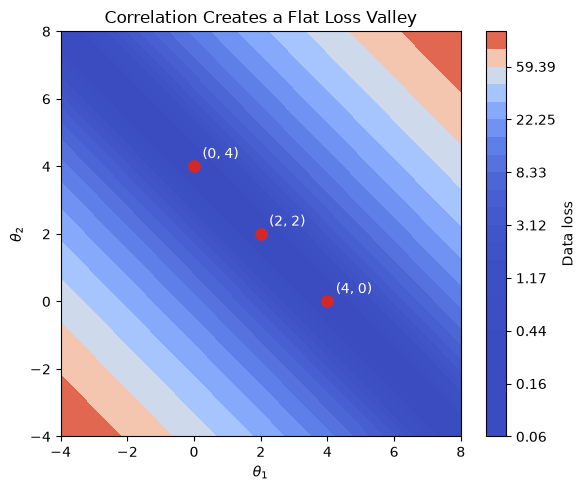

In [6]:
rng = np.random.default_rng(26)
x_1 = rng.normal(0, 1, 50)
x_2 = x_1 + rng.normal(0, 0.05, 50)
y_example = 4 * x_1 + rng.normal(0, 0.30, 50)

values = np.linspace(-4, 8, 250)
theta_1, theta_2 = np.meshgrid(values, values)
prediction = theta_1[:, :, None] * x_1 + theta_2[:, :, None] * x_2
loss = 0.5 * np.mean((y_example - prediction) ** 2, axis=2)
pairs = np.array([[4, 0], [2, 2], [0, 4]])
levels = np.geomspace(loss.min(), loss.max(), 24)

fig, ax = plt.subplots(figsize=(6, 5))
filled = ax.contourf(theta_1, theta_2, loss, levels=levels, cmap="coolwarm")
ax.scatter(pairs[:, 0], pairs[:, 1], s=65, color="C3")
for t_1, t_2 in pairs:
    ax.annotate(f"({t_1}, {t_2})", (t_1, t_2), xytext=(6, 6), textcoords="offset points", color="white")
ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", title="Correlation Creates a Flat Loss Valley")
fig.colorbar(filled, ax=ax, label="Data loss")
fig.tight_layout()
plt.show()

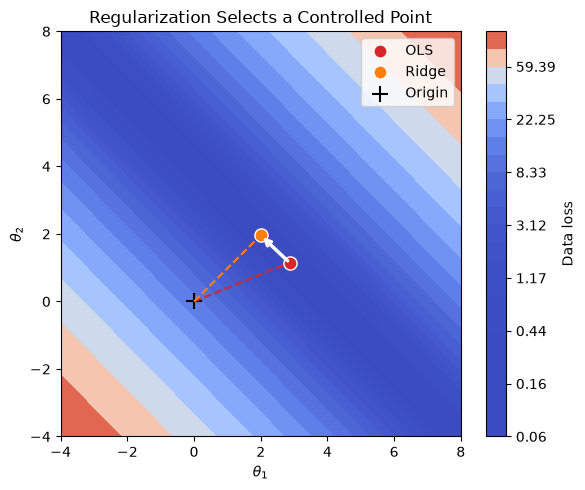

In [7]:
X_example = np.column_stack([x_1, x_2])
theta_ols_example = LinearRegression(fit_intercept=False).fit(X_example, y_example).coef_
theta_ridge_example = Ridge(alpha=2.5, fit_intercept=False).fit(X_example, y_example).coef_

fig, ax = plt.subplots(figsize=(6, 5))
filled = ax.contourf(theta_1, theta_2, loss, levels=levels, cmap="coolwarm")

# The penalty prefers a shorter parameter vector, closer to the origin.
ax.plot([0, theta_ols_example[0]], [0, theta_ols_example[1]], "--", color="C3")
ax.plot([0, theta_ridge_example[0]], [0, theta_ridge_example[1]], "--", color="C1")
ax.annotate("", xy=theta_ridge_example, xytext=theta_ols_example, arrowprops={"arrowstyle": "->", "color": "white", "linewidth": 2.5})
ax.scatter(*theta_ols_example, s=90, color="C3", edgecolor="white", label="OLS")
ax.scatter(*theta_ridge_example, s=90, color="C1", edgecolor="white", label="Ridge")
ax.scatter(0, 0, marker="+", s=120, color="black", label="Origin")
ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", title="Regularization Selects a Controlled Point")
ax.legend()
fig.colorbar(filled, ax=ax, label="Data loss")
fig.tight_layout()
plt.show()

## 4. Ridge regression stabilizes the parameters

Ridge regression balances prediction error against squared parameter size:

$$
\hat{\theta}_{\mathrm{ridge}}
=
\underset{\theta}{\operatorname{argmin}}
\left[
\frac{1}{2n}\lVert\mathbf y-\mathbf X\theta\rVert_2^2
+
\frac{\lambda}{2}\lVert\theta\rVert_2^2
\right].
$$

Large parameters become expensive, so Ridge moves the solution toward zero. The intercept is fitted separately and is not penalized by \`Ridge\`.

### 4.1 Ridge before standardization

We first apply Ridge directly to the absorbance columns. The penalty acts on parameter values expressed in their original feature units.

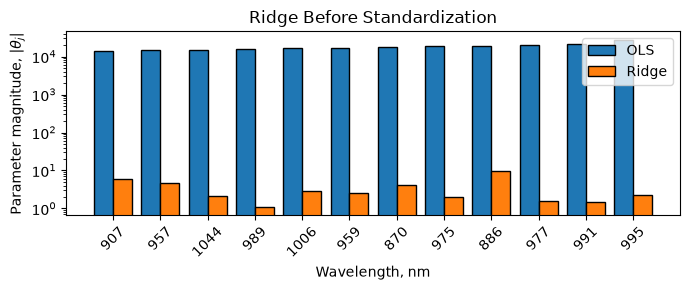

In [8]:
ols_raw = LinearRegression().fit(X_train, y_train)
ridge_raw = Ridge(alpha=0.1).fit(X_train, y_train)
selected_raw = np.argsort(np.abs(ols_raw.coef_))[-12:]
positions = np.arange(len(selected_raw))

# Large OLS values are a symptom of unstable weight sharing among correlated wavelengths.
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(positions - 0.2, np.abs(ols_raw.coef_[selected_raw]), 0.4, edgecolor="black", label="OLS")
ax.bar(positions + 0.2, np.abs(ridge_raw.coef_[selected_raw]), 0.4, edgecolor="black", label="Ridge")
ax.set_yscale("log")
ax.set_xticks(positions, [f"{wavelengths[i]:.0f}" for i in selected_raw], rotation=45)
ax.set(xlabel="Wavelength, nm", ylabel=r"Parameter magnitude, $|\theta_j|$", title="Ridge Before Standardization")
ax.legend()
fig.tight_layout()
plt.show()

### 4.2 Standardize before applying the penalty

A parameter depends on the units of its feature. Standardization places every feature on a comparable scale:

$$
z_{ij}=\frac{x_{ij}-\bar{x}_j}{s_j}.
$$

The scaler is fitted only on the training data. The same training mean and standard deviation are then applied to the test data.

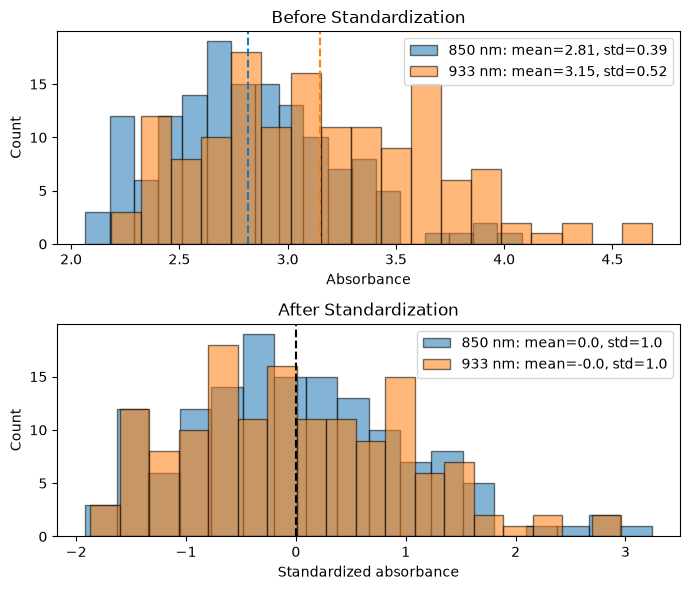

In [9]:
feature_indices = [0, 41]
feature_labels = ["850 nm", "933 nm"]
X_two = X_train[:, feature_indices]

# Use training samples so these means and standard deviations match the fitted scaler.
X_two_scaled = StandardScaler().fit_transform(X_two)
fig, ax = plt.subplots(2, 1, figsize=(7, 6))

for i, label in enumerate(feature_labels):
    ax[0].hist(X_two[:, i], bins=18, alpha=0.55, edgecolor="black", label=f"{label}: mean={X_two[:, i].mean():.2f}, std={X_two[:, i].std():.2f}")
    ax[0].axvline(X_two[:, i].mean(), color=f"C{i}", linestyle="--")
    ax[1].hist(X_two_scaled[:, i], bins=18, alpha=0.55, edgecolor="black", label=f"{label}: mean={X_two_scaled[:, i].mean():.1f}, std={X_two_scaled[:, i].std():.1f}")

ax[0].set(xlabel="Absorbance", ylabel="Count", title="Before Standardization")
ax[1].axvline(0, color="black", linestyle="--")
ax[1].set(xlabel="Standardized absorbance", ylabel="Count", title="After Standardization")
ax[0].legend()
ax[1].legend()
fig.tight_layout()
plt.show()

OLS training RMSE: 1.0024155309803329
OLS test RMSE: 4.418206295308005
Ridge training RMSE: 3.0193844177165263
Ridge test RMSE: 4.10265865752087


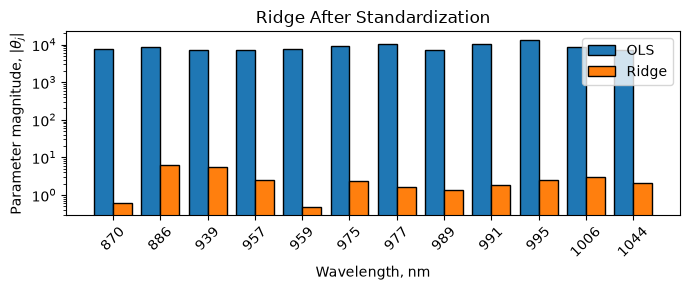

In [10]:
scaler = StandardScaler()

# Fit only on training data; fitting on all samples would leak test information.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ols = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=0.1).fit(X_train_scaled, y_train)

print("OLS training RMSE:", root_mean_squared_error(y_train, ols.predict(X_train_scaled)))
print("OLS test RMSE:", root_mean_squared_error(y_test, ols.predict(X_test_scaled)))
print("Ridge training RMSE:", root_mean_squared_error(y_train, ridge.predict(X_train_scaled)))
print("Ridge test RMSE:", root_mean_squared_error(y_test, ridge.predict(X_test_scaled)))

selected = np.sort(np.argsort(np.abs(ols.coef_))[-12:])
x_position = np.arange(len(selected))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(x_position - 0.2, np.abs(ols.coef_[selected]), 0.4, edgecolor="black", label="OLS")
ax.bar(x_position + 0.2, np.abs(ridge.coef_[selected]), 0.4, edgecolor="black", label="Ridge")
ax.set_yscale("log")
ax.set_xticks(x_position, [f"{wavelengths[i]:.0f}" for i in selected], rotation=45)
ax.set(xlabel="Wavelength, nm", ylabel=r"Parameter magnitude, $|\theta_j|$", title="Ridge After Standardization")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Alpha controls Ridge shrinkage

In scikit-learn, \`alpha\` controls the regularization strength.

- A small \`alpha\` stays close to ordinary least squares.
- Increasing \`alpha\` reduces the parameter norm.
- Too large alpha can underfit the model.

The following sweep illustrates the behavior. It does not select an optimal \`alpha\`; model selection requires separate validation data or cross-validation.

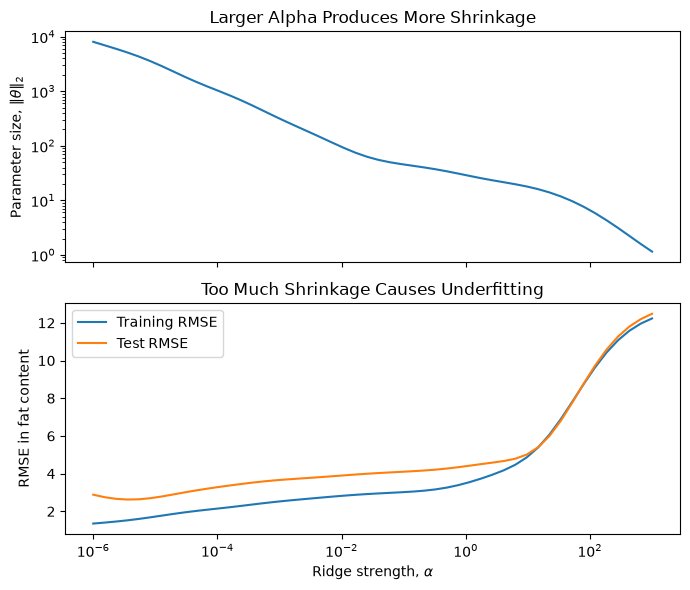

In [11]:
alpha_values = np.logspace(-6, 3, 50)
parameter_size, train_rmse, test_rmse = [], [], []

# This sweep shows behavior only; it is not used to choose alpha.
for alpha in alpha_values:
    model = Ridge(alpha=alpha).fit(X_train_scaled, y_train)
    parameter_size.append(np.linalg.norm(model.coef_))
    train_rmse.append(root_mean_squared_error(y_train, model.predict(X_train_scaled)))
    test_rmse.append(root_mean_squared_error(y_test, model.predict(X_test_scaled)))

fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].loglog(alpha_values, parameter_size)
ax[0].set(ylabel=r"Parameter size, $\|\theta\|_2$", title="Larger Alpha Produces More Shrinkage")
ax[1].semilogx(alpha_values, train_rmse, label="Training RMSE")
ax[1].semilogx(alpha_values, test_rmse, label="Test RMSE")
ax[1].set(xlabel=r"Ridge strength, $\alpha$", ylabel="RMSE in fat content", title="Too Much Shrinkage Causes Underfitting")
ax[1].legend()
fig.tight_layout()
plt.show()

## 6. Lasso can set parameters exactly to zero

Lasso uses the absolute parameter size:

$$
\hat{\theta}_{\mathrm{lasso}}
=
\underset{\theta}{\operatorname{argmin}}
\left[
\frac{1}{2n}\lVert\mathbf y-\mathbf X\theta\rVert_2^2
+
\lambda\lVert\theta\rVert_1
\right].
$$

For one standardized feature,

$$
z_j=\frac{1}{n}\mathbf x_j^T\mathbf y,
\qquad
\hat{\theta}_j=\operatorname{sign}(z_j)\max(|z_j|-\lambda,0).
$$

Therefore, $|z_j|\leq\lambda$ gives $\hat{\theta}_j=0$. With several correlated features, the same soft-thresholding operation is used during coordinate descent with the partial residual replacing $\mathbf y$.

Training RMSE: 4.043958036941804
Test RMSE: 4.771485599877072
Retained wavelengths: 25
Parameters set to zero: 75


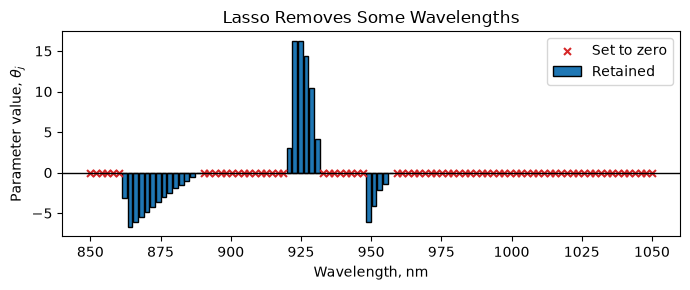

In [12]:
lasso = Lasso(alpha=0.1, tol=0.01).fit(X_train_scaled, y_train)
nonzero = np.abs(lasso.coef_) > 1e-8

print("Training RMSE:", root_mean_squared_error(y_train, lasso.predict(X_train_scaled)))
print("Test RMSE:", root_mean_squared_error(y_test, lasso.predict(X_test_scaled)))
print("Retained wavelengths:", nonzero.sum())
print("Parameters set to zero:", (~nonzero).sum())

# A zero parameter removes that wavelength from this fitted predictive model.
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(wavelengths[nonzero], lasso.coef_[nonzero], width=1.7, edgecolor="black", label="Retained")
ax.scatter(wavelengths[~nonzero], np.zeros((~nonzero).sum()), color="C3", marker="x", s=25, label="Set to zero")
ax.axhline(0, color="black", linewidth=1)
ax.set(xlabel="Wavelength, nm", ylabel=r"Parameter value, $\theta_j$", title="Lasso Removes Some Wavelengths")
ax.legend()
fig.tight_layout()
plt.show()

### 6.1 Alpha controls how many wavelengths remain

Increasing Lasso strength generally leaves fewer nonzero parameters. The count does not have to decrease smoothly because correlated wavelengths can replace one another.

As in the Ridge example, this is only a behavior illustration. We do not use the test curve to choose \`alpha\`.

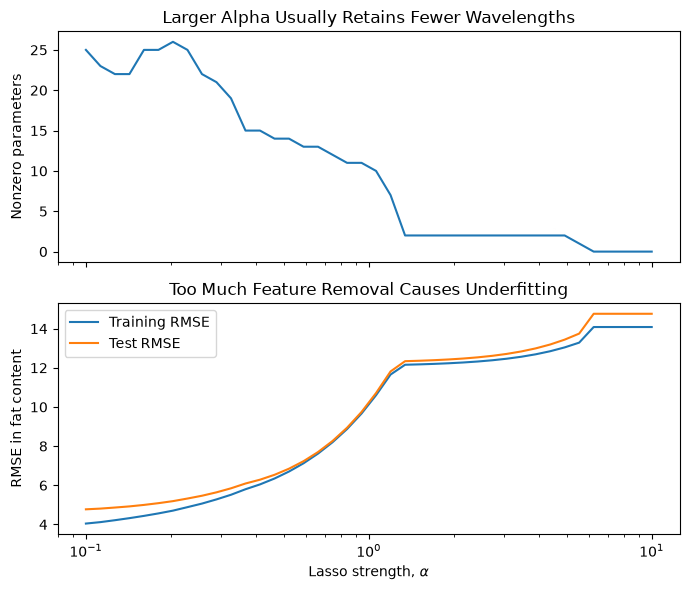

In [13]:
lasso_alphas = np.logspace(-1, 1, 40)
nonzero_count, lasso_train_rmse, lasso_test_rmse = [], [], []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, tol=0.01).fit(X_train_scaled, y_train)
    nonzero_count.append(np.count_nonzero(model.coef_))
    lasso_train_rmse.append(root_mean_squared_error(y_train, model.predict(X_train_scaled)))
    lasso_test_rmse.append(root_mean_squared_error(y_test, model.predict(X_test_scaled)))

fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax[0].semilogx(lasso_alphas, nonzero_count)
ax[0].set(ylabel="Nonzero parameters", title="Larger Alpha Usually Retains Fewer Wavelengths")
ax[1].semilogx(lasso_alphas, lasso_train_rmse, label="Training RMSE")
ax[1].semilogx(lasso_alphas, lasso_test_rmse, label="Test RMSE")
ax[1].set(xlabel=r"Lasso strength, $\alpha$", ylabel="RMSE in fat content", title="Too Much Feature Removal Causes Underfitting")
ax[1].legend()
fig.tight_layout()
plt.show()

## 7. Interpreting the selected wavelengths

A nonzero Lasso parameter means that the wavelength belongs to a useful sparse predictive set for this fitted model. It does not prove that the wavelength is the only chemically important one.

Neighboring wavelengths are strongly correlated, so one wavelength can often replace another. The selected set may change when the data or regularization strength changes.

## 8. Elastic Net combines Ridge and Lasso

Ridge is helpful when many wavelengths are correlated. Lasso is helpful when we want a smaller set of wavelengths. Elastic Net uses both ideas:

$$
\frac{1}{2n}\lVert\mathbf y-\mathbf X\theta\rVert_2^2
+\alpha\rho\lVert\theta\rVert_1
+\frac{\alpha(1-\rho)}{2}\lVert\theta\rVert_2^2.
$$

Here, $\rho$ is called `l1_ratio` in scikit-learn. A value near 1 behaves more like Lasso; a value near 0 behaves more like Ridge. We use one fixed setting below only for demonstration.

In [14]:
elastic_net = ElasticNet(alpha=0.05, l1_ratio=0.8, tol=0.03).fit(X_train_scaled, y_train)
elastic_nonzero = np.count_nonzero(np.abs(elastic_net.coef_) > 1e-8)

print("Training RMSE:", root_mean_squared_error(y_train, elastic_net.predict(X_train_scaled)))
print("Test RMSE:", root_mean_squared_error(y_test, elastic_net.predict(X_test_scaled)))
print("Retained wavelengths:", elastic_nonzero)

Training RMSE: 3.935747171192425
Test RMSE: 4.573676881525187
Retained wavelengths: 65


### Compare predictions with parity plots

A point on the dashed line has perfect agreement between measured and predicted fat content. The same test samples and axes are used in every panel, so the comparison is direct.

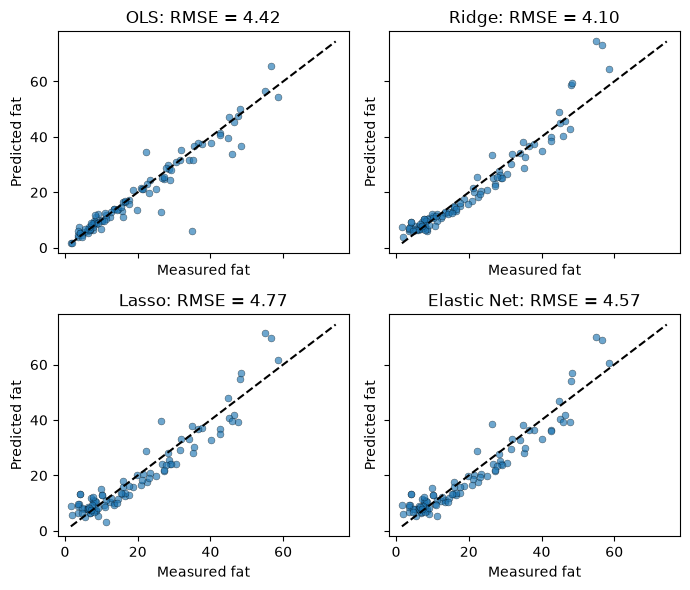

In [15]:
models = [("OLS", ols), ("Ridge", ridge), ("Lasso", lasso), ("Elastic Net", elastic_net)]
predictions = [model.predict(X_test_scaled) for name, model in models]
lower = min(y_test.min(), min(values.min() for values in predictions))
upper = max(y_test.max(), max(values.max() for values in predictions))

fig, ax = plt.subplots(2, 2, figsize=(7, 6), sharex=True, sharey=True)
for axis, (name, model), predicted in zip(ax.ravel(), models, predictions):
    rmse = root_mean_squared_error(y_test, predicted)
    axis.scatter(y_test, predicted, s=25, alpha=0.65, edgecolor="black", linewidth=0.3)
    # The dashed line is perfect agreement: predicted fat equals measured fat.
    axis.plot([lower, upper], [lower, upper], "k--")
    axis.set(xlabel="Measured fat", ylabel="Predicted fat", title=f"{name}: RMSE = {rmse:.2f}")

fig.tight_layout()
plt.show()

## Main points

- Ridge shrinks correlated parameters but usually keeps every wavelength.
- Lasso can set some parameters to zero.
- Elastic Net combines shrinkage and sparsity.
- Standardize the features before applying any of these penalties.
- Choose regularization settings with validation data, not with the final test set.